In [22]:
import pandas as pd 
# On charge le fichier CSV. encoding='latin-1' est nécessaire car ce fichier
# contient des caractères spéciaux que l'encodage par défaut (utf-8) ne lit pas bien
df = pd.read_csv('spam.csv', encoding='latin-1')

# Affiche les 5 premières lignes
df.head(100)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
96,ham,Watching telugu movie..wat abt u?,NaN,NaN,NaN
97,ham,i see. When we finish we have loads of loans t...,NaN,NaN,NaN
98,ham,Hi. Wk been ok - on hols now! Yes on for a bit...,NaN,NaN,NaN


In [23]:
df.shape
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [24]:
df['Unnamed: 2'].value_counts()

Unnamed: 2
 bt not his girlfrnd... G o o d n i g h t . . .@"                                                                                                   3
 PO Box 5249                                                                                                                                        2
this wont even start........ Datz confidence.."                                                                                                     2
GN                                                                                                                                                  2
 don't miss ur best life for anything... Gud nyt..."                                                                                                2
 but dont try to prove it..\" .Gud noon...."                                                                                                        2
 the person is definitely special for u..... But if the person is so special             

In [25]:
# On garde uniquement les colonnes utiles
df = df[['v1', 'v2']]

# On les renomme pour que ce soit clair
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
print("Valeurs manquantes :", df.isnull().sum())
print("Nombre de doublons :", df.duplicated().sum())

Valeurs manquantes : label      0
message    0
dtype: int64
Nombre de doublons : 403


In [27]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Nouvelle taille du dataset :", df.shape)

Nouvelle taille du dataset : (5169, 2)


In [28]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [29]:
df['label'].value_counts()
df['label'].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

C:\Users\hello\AppData\Local\Temp\ipykernel_20300\280902569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#4C72B0', '#DD8452'])


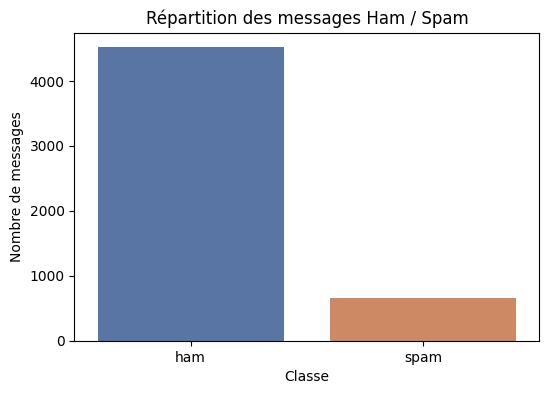

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['#4C72B0', '#DD8452'])
plt.title("Répartition des messages Ham / Spam")
plt.xlabel("Classe")
plt.ylabel("Nombre de messages")
plt.show()

In [31]:
df['message_length'] = df['message'].apply(len)

df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


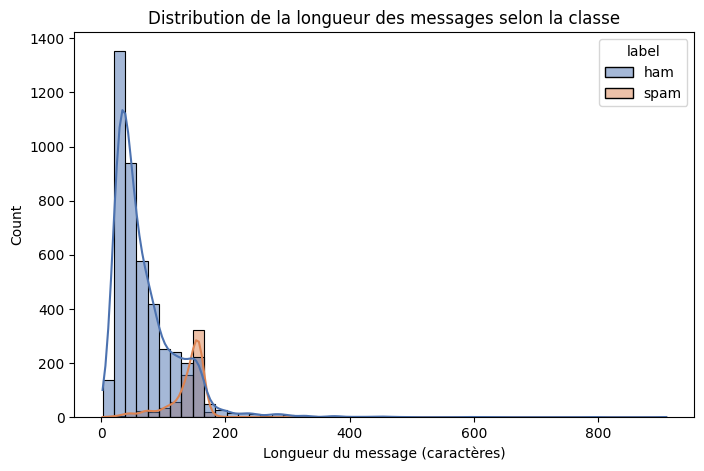

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette=['#4C72B0', '#DD8452'])
plt.title("Distribution de la longueur des messages selon la classe")
plt.xlabel("Longueur du message (caractères)")
plt.show()

In [33]:
!pip install wordcloud

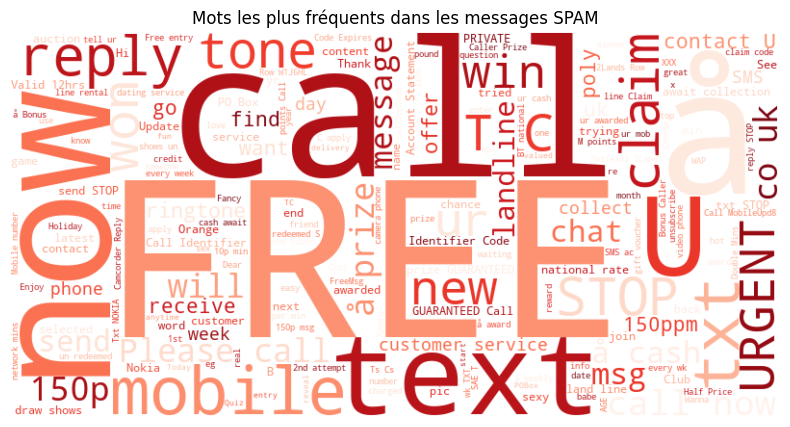

In [34]:
from wordcloud import WordCloud

spam_text = ' '.join(df[df['label'] == 'spam']['message'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Mots les plus fréquents dans les messages SPAM")
plt.show()

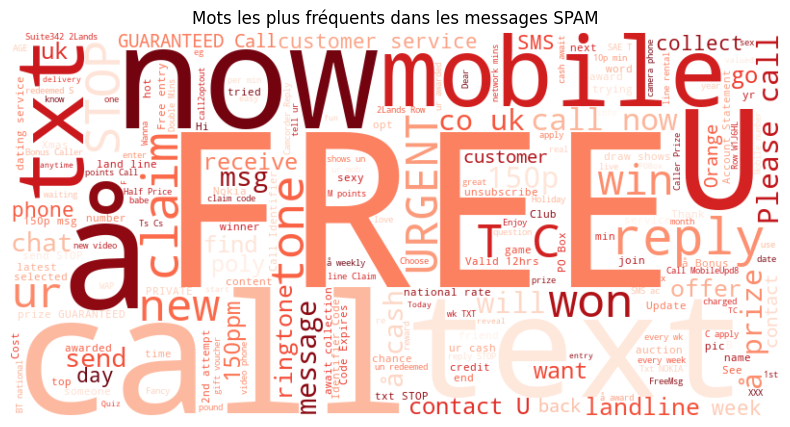

In [35]:
spam_text = ' '.join(df[df['label'] == 'spam']['message'])     # ← filtre "spam"
wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_text)  # ← couleur rouge

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Mots les plus fréquents dans les messages SPAM")
plt.show()

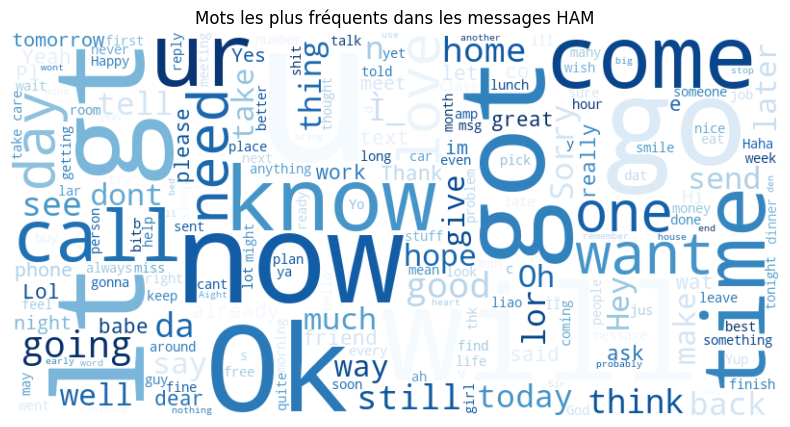

In [36]:
ham_text = ' '.join(df[df['label'] == 'ham']['message'])
wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Mots les plus fréquents dans les messages HAM")
plt.show()

In [37]:
import sys
!{sys.executable} -m pip install nltk

In [38]:
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                    # tout en minuscules
    text = re.sub(r'http\S+|www\S+', '', text)              # supprime les liens
    text = text.translate(str.maketrans('', '', string.punctuation))  # supprime ponctuation
    text = re.sub(r'\d+', '', text)                         # supprime les chiffres
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]  # supprime mots vides
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hello\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months entitled update latest colour mo...


In [18]:
import sys
!{sys.executable} -m pip install scikit-learn nltk wordcloud pandas matplotlib seaborn joblib

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Taille train:", X_train_tfidf.shape)
print("Taille test:", X_test_tfidf.shape)

Taille train: (4135, 3000)
Taille test: (1034, 3000)


In [40]:
import sys
print(sys.executable)

c:\Users\hello\anaconda3\python\envs\Pytorch\python.exe


In [41]:
import sys
!{sys.executable} -m pip install scikit-learn nltk wordcloud joblib

In [42]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    'Naive Bayes': MultinomialNB(),
    'Regression Logistique': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear', probability=True, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print(f"{name} entraîné avec succès.")

Naive Bayes entraîné avec succès.
Regression Logistique entraîné avec succès.


c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM entraîné avec succès.


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = {}
predictions = {}

# CHANGEMENT ICI : on fusionne la baseline avec tes 3 modèles dans un seul dictionnaire
all_models = {'Baseline (classe majoritaire)': baseline, **trained_models}

for name, model in all_models.items():   # <-- on boucle sur all_models, pas trained_models
    preds = model.predict(X_test_tfidf)
    predictions[name] = preds
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-score': f1_score(y_test, preds, zero_division=0)
    }

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1-score
Baseline (classe majoritaire),0.8733,0.0000,0.0000,0.0000
Naive Bayes,0.9710,0.9903,0.7786,0.8718
Regression Logistique,0.9584,0.9889,0.6794,0.8054
SVM,0.9787,0.9739,0.8550,0.9106


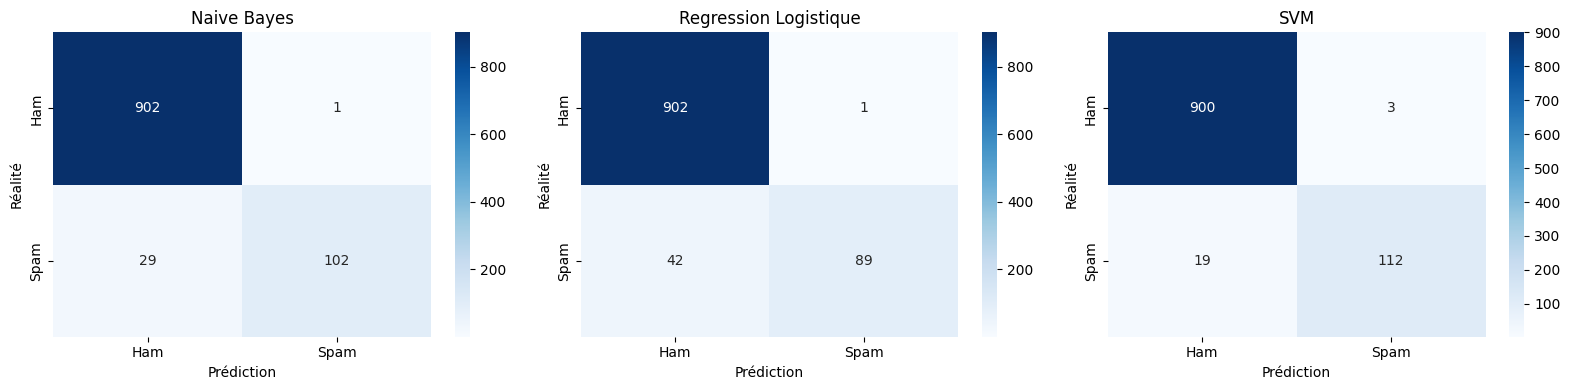

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(name)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")

plt.tight_layout()
plt.show()

In [48]:
from sklearn.dummy import DummyClassifier

# strategy='most_frequent' = prédit toujours la classe majoritaire (ham)
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_tfidf, y_train)
baseline_preds = baseline.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_precision = precision_score(y_test, baseline_preds, zero_division=0)
baseline_recall = recall_score(y_test, baseline_preds, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_preds, zero_division=0)

print(f"Baseline - Accuracy  : {baseline_accuracy:.4f}")
print(f"Baseline - Precision : {baseline_precision:.4f}")
print(f"Baseline - Recall    : {baseline_recall:.4f}")
print(f"Baseline - F1-score  : {baseline_f1:.4f}")

Baseline - Accuracy  : 0.8733
Baseline - Precision : 0.0000
Baseline - Recall    : 0.0000
Baseline - F1-score  : 0.0000


In [50]:
from sklearn.model_selection import cross_val_score
import numpy as np

# On refait le TF-IDF sur TOUT le dataset nettoyé (pas juste le train),
# car cross_val_score gère lui-même les découpages train/test en interne
X_full_tfidf = vectorizer.fit_transform(df['clean_message'])
y_full = df['label_num']

print("Validation croisée (5-fold) - F1-score\n")

for name, model in trained_models.items():
    scores = cross_val_score(model, X_full_tfidf, y_full, cv=5, scoring='f1')
    print(f"{name} : {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"   Scores détaillés sur les 5 plis : {np.round(scores, 4)}\n")

Validation croisée (5-fold) - F1-score

Naive Bayes : 0.8820 (+/- 0.0178)
   Scores détaillés sur les 5 plis : [0.9167 0.8658 0.8755 0.8755 0.8766]

Regression Logistique : 0.7818 (+/- 0.0383)
   Scores détaillés sur les 5 plis : [0.8398 0.722  0.7854 0.7671 0.7945]



c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probab

SVM : 0.9065 (+/- 0.0130)
   Scores détaillés sur les 5 plis : [0.9163 0.9083 0.9174 0.9091 0.8816]



In [51]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# On construit un pipeline : TF-IDF -> SVM, comme une chaîne de traitement
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC(kernel='linear', random_state=42))  # sans probability=True ici, pour aller plus vite
])

# La grille de paramètres à tester : le préfixe (tfidf__ ou clf__) indique
# à quelle étape du pipeline appartient chaque paramètre
param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],   # unigrammes seuls, ou unigrammes + bigrammes
    'clf__C': [0.1, 1, 10]                     # force de régularisation du SVM
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(df['clean_message'], df['label_num'])

print("Meilleurs paramètres trouvés :", grid_search.best_params_)
print(f"Meilleur F1-score (validation croisée) : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Meilleurs paramètres trouvés : {'clf__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Meilleur F1-score (validation croisée) : 0.9122


In [45]:
import joblib

joblib.dump(trained_models['SVM'], 'spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Modèle SVM sauvegardé sous 'spam_model.pkl'")
print("Vectorizer TF-IDF sauvegardé sous 'tfidf_vectorizer.pkl'")

Modèle SVM sauvegardé sous 'spam_model.pkl'
Vectorizer TF-IDF sauvegardé sous 'tfidf_vectorizer.pkl'


In [53]:
# Nouveau vectorizer avec les meilleurs paramètres trouvés par GridSearchCV
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# On refait la vectorisation UNIQUEMENT sur X_train et X_test (pas tout le dataset)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Nouveau SVM avec le meilleur C trouvé (ici C=1, donc identique à avant en réalité)
svm_final = SVC(kernel='linear', C=1, probability=True, random_state=42)
svm_final.fit(X_train_tfidf, y_train)

# On remplace le SVM dans trained_models par cette version optimisée
trained_models['SVM'] = svm_final

# On revérifie les métriques avec ce nouveau modèle
preds = svm_final.predict(X_test_tfidf)
print(f"Nouveau F1-score (test) : {f1_score(y_test, preds):.4f}")

c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Nouveau F1-score (test) : 0.9231


In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4135,)
(1034,)
(4135,)
(1034,)


In [54]:
import joblib

joblib.dump(svm_final, 'spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Modèle et vectorizer mis à jour et sauvegardés.")

Modèle et vectorizer mis à jour et sauvegardés.


In [47]:
def predict_message(text, model, vectorizer):
    cleaned = clean_text(text)
    vect = vectorizer.transform([cleaned])
    pred = model.predict(vect)[0]
    return "SPAM" if pred == 1 else "HAM (normal)"

exemples = [
    "congratulation you have win a new moto!",
    "how are you bro?",
]

for msg in exemples:
    print(f"Message : {msg}")
    print(f"Prédiction : {predict_message(msg, trained_models['SVM'], vectorizer)}\n")

Message : congratulation you have win a new moto!
Prédiction : SPAM

Message : how are you bro?
Prédiction : HAM (normal)



In [55]:
# On reconstruit un tableau complet : message original, message nettoyé, vrai label, prédiction
resultats_test = pd.DataFrame({
    'message_original': df.loc[X_test.index, 'message'],
    'message_nettoye': X_test,
    'vrai_label': y_test,
    'prediction': preds
})

# Ajout d'une colonne lisible (Ham/Spam) plutôt que 0/1
resultats_test['vrai_label_txt'] = resultats_test['vrai_label'].map({0: 'Ham', 1: 'Spam'})
resultats_test['prediction_txt'] = resultats_test['prediction'].map({0: 'Ham', 1: 'Spam'})

# FAUX NÉGATIFS : vrais spams que le modèle a classés comme ham (les plus dangereux, cf. discussion Recall)
faux_negatifs = resultats_test[(resultats_test['vrai_label'] == 1) & (resultats_test['prediction'] == 0)]

# FAUX POSITIFS : vrais ham que le modèle a bloqués à tort comme spam
faux_positifs = resultats_test[(resultats_test['vrai_label'] == 0) & (resultats_test['prediction'] == 1)]

print(f"Nombre de faux négatifs (spams manqués) : {len(faux_negatifs)}")
print(f"Nombre de faux positifs (ham bloqués à tort) : {len(faux_positifs)}\n")

print("=== Exemples de FAUX NÉGATIFS (spams manqués) ===")
for msg in faux_negatifs['message_original'].head(5):
    print(f"- {msg}\n")

print("=== Exemples de FAUX POSITIFS (ham bloqués à tort) ===")
for msg in faux_positifs['message_original'].head(5):
    print(f"- {msg}\n")

Nombre de faux négatifs (spams manqués) : 17
Nombre de faux positifs (ham bloqués à tort) : 2

=== Exemples de FAUX NÉGATIFS (spams manqués) ===
- You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750

- Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Callså£1/minMobsmoreLKPOBOX177HP51FL

- ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O å£250 3 WANT å£800

- Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 09099726395 Lucy x Callså£1/minMobsmoreLKPOBOX177HP51FL

- Missed call alert. These numbers called but left no message. 07008009200

=== Exemples de FAUX POSITIFS (ham bloqués à tort) ===
- I am waiting machan. Call me once you free.

- K k:) sms chat with me.



In [57]:
# On réentraîne la Régression Logistique "normale" avec le NOUVEAU vectorizer (5000 features)
logreg_normal = LogisticRegression(max_iter=1000)
logreg_normal.fit(X_train_tfidf, y_train)
preds_logreg_normal = logreg_normal.predict(X_test_tfidf)

In [62]:
# On teste class_weight='balanced' sur la Régression Logistique et le SVM
logreg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_balanced.fit(X_train_tfidf, y_train)
preds_logreg_balanced = logreg_balanced.predict(X_test_tfidf)

svm_balanced = SVC(kernel='linear', C=1, class_weight='balanced', probability=True, random_state=42)
svm_balanced.fit(X_train_tfidf, y_train)
preds_svm_balanced = svm_balanced.predict(X_test_tfidf)

# Tableau comparatif avant/après rééquilibrage
comparaison_balanced = pd.DataFrame({
    'Régression Logistique (normale)': {
        'Precision': precision_score(y_test, preds_logreg_normal),
        'Recall': recall_score(y_test,  preds_logreg_normal),
        'F1-score': f1_score(y_test, preds_logreg_normal)
    },
    'Régression Logistique (balanced)': {
        'Precision': precision_score(y_test, preds_logreg_balanced),
        'Recall': recall_score(y_test, preds_logreg_balanced),
        'F1-score': f1_score(y_test, preds_logreg_balanced)
    },
    'SVM (normal)': {
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds)
    },
    'SVM (balanced)': {
        'Precision': precision_score(y_test, preds_svm_balanced),
        'Recall': recall_score(y_test, preds_svm_balanced),
        'F1-score': f1_score(y_test, preds_svm_balanced)
    }
}).T.round(4)

comparaison_balanced

c:\Users\hello\anaconda3\python\envs\Pytorch\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Precision,Recall,F1-score
Régression Logistique (normale),0.9884,0.6489,0.7834
Régression Logistique (balanced),0.8750,0.9084,0.8914
SVM (normal),0.9828,0.8702,0.9231
SVM (balanced),0.9200,0.8779,0.8984


In [63]:
comparaison_balanced = pd.DataFrame({
    'Régression Logistique (normale)': {
        'Precision': precision_score(y_test, preds_logreg_normal),
        'Recall': recall_score(y_test, preds_logreg_normal),
        'F1-score': f1_score(y_test, preds_logreg_normal)
    },
    'Régression Logistique (balanced)': {
        'Precision': precision_score(y_test, preds_logreg_balanced),
        'Recall': recall_score(y_test, preds_logreg_balanced),
        'F1-score': f1_score(y_test, preds_logreg_balanced)
    },
    'SVM (normal)': {
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds)
    },
    'SVM (balanced)': {
        'Precision': precision_score(y_test, preds_svm_balanced),
        'Recall': recall_score(y_test, preds_svm_balanced),
        'F1-score': f1_score(y_test, preds_svm_balanced)
    }
}).T.round(4)

comparaison_balanced

,Precision,Recall,F1-score
Régression Logistique (normale),0.9884,0.6489,0.7834
Régression Logistique (balanced),0.8750,0.9084,0.8914
SVM (normal),0.9828,0.8702,0.9231
SVM (balanced),0.9200,0.8779,0.8984


In [64]:
preds_final = svm_final.predict(X_test_tfidf)
print("Accuracy :", round(accuracy_score(y_test, preds_final), 4))
print("Precision:", round(precision_score(y_test, preds_final), 4))
print("Recall   :", round(recall_score(y_test, preds_final), 4))
print("F1-score :", round(f1_score(y_test, preds_final), 4))

Accuracy : 0.9816
Precision: 0.9828
Recall   : 0.8702
F1-score : 0.9231


In [ ]:
import joblib

# Sauvegarde du modèle et du vectoriseur
joblib.dump(model, 'src/spam_model.pkl')
joblib.dump(vectorizer, 'src/tfidf_vectorizer.pkl')

print("Fichiers .pkl sauvegardés avec succès !")